# HAL-TMLE-RC v1 API Demo

This notebook demonstrates the package API for right-censored survival targeting in its current v1 form.

Locked design choices:
- fit one reverse Kaplan-Meier from observed data `(tilde T, Delta)` and reuse the same fitted KM object throughout;
- keep the existing IPCW HAL initializer unchanged;
- compute one pointwise scalar update per target time `t0`;
- use an augmented quadrature grid for each `t0`;
- estimate pointwise survival variance through the empirical EIC.


In [1]:
import os
import sys
import pathlib
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_path = candidate / 'src'
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str((ROOT / '.matplotlib').resolve()))

from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.utils import TruncatedGMM

from haldensity.targeting import (
    RightCensoredSurvivalTargetLearner,
    right_censored_survival_targeting_M_step,
    right_censored_survival_estimand_variance,
)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup and Evaluation Conventions

We work with observed data `(tilde T, Delta)` where `tilde T = min(T, C)` and `Delta = I(T <= C)`.
The Stage 1 fit follows the same IPCW convention and estimator path as the current right-censoring workflow, but the notebook manually refits the tuned initializer so the package targeting API can reuse the same fitted KM object.

Implementation conventions used throughout this demo:
- use right-continuous `\bar G_n(t)` in every denominator appearing in `D_{F_n,G_n}` where the derivation specifies `\bar G(t)`;
- keep the repo's existing Stage 1 IPCW convention unchanged;
- for each pointwise TMLE problem, start from the stored HAL grid and augment the quadrature breakpoints with the current target time `t0`;
- evaluate density and the fluctuation direction on the resulting pointwise midpoint grid;
- compute survival from edge-based suffix sums on that augmented grid using `delta_j`;
- estimate pointwise variance by the empirical variance of the EIC divided by `n`.


In [2]:
RNG_SEED = 42
N = 180
CV_FOLDS = 5
N_TRIALS = 20  # keep the demo quick; increase for a more stable Stage 1 fit
N_GRID_POINTS = 200
BASIS_ORDER_OPTIONS = [2]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-50.0, 50.0)
TARGET_TIMES = np.linspace(0.05, 0.95, 20)
FOCUS_T0 = 0.5
np.random.seed(RNG_SEED)


In [3]:
# 1) Generate synthetic right-censored data
sampler_params = {
    'components': [
        {'mean': 0.2, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.8, 'std': 0.05, 'lower': 0, 'upper': 1},
    ],
    'weights': [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(**sampler_params)
event_times = sampler.generate_samples(N)
censor_times = np.random.uniform(0, 1, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({'T': tilde_T, 'Delta': Delta})

print(f'n={N}, uncensored={Delta.sum()}, censored={N - Delta.sum()}')
print(f'censoring rate: {1 - Delta.mean():.1%}')
data.head()


n=180, uncensored=95, censored=85
censoring rate: 47.2%


,T,Delta
0,0.528144,1
1,0.435673,0
2,0.481872,1
3,0.047716,0
4,0.440205,1


In [4]:
# 2) Tune Stage 1, then refit Stage 1 manually with one KM object shared with the TMLE layer
init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col='T', delta_col='Delta')
shared_weights = compute_ipcw_weights(
    T=data['T'].to_numpy(),
    Delta=data['Delta'].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data['Delta'].to_numpy() == 1
uncensored_df = pd.DataFrame({'W1': data.loc[uncensored_mask, 'T'].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params['norm_constraint']),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params['basis_order']),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

print('Stage 1 tuning best params:', tuned_init.best_params)
print('Stage 1 selected knots:', int(stage1_estimator.get_results()['n_selected_knots']))
print('KM shared between Stage 1 refit and TMLE layer:', isinstance(km_shared, KaplanMeier))


Stage 1 tuning best params: {'norm_constraint': 963.3551080156752, 'basis_order': 2}
Stage 1 selected knots: 21
KM shared between Stage 1 refit and TMLE layer: True


In [5]:
# 3) The right-censored TMLE logic now lives in the package API imported above
learner = RightCensoredSurvivalTargetLearner(
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)


In [6]:
# 4) Run one pointwise targeted fit for the focus time through the package API
focus_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
focus_result = focus_targeted['pointwise_fits'][0]
focus_initial_fit = focus_targeted['initial_fit']
focus_censoring_cache = focus_targeted['censoring_cache']


In [7]:
pd.Series({
    "t0": focus_result['t0'],
    "psi_init": focus_result['psi_init'],
    "psi_star": focus_result['psi_star'],
    "epsilon": focus_result['epsilon'],
    "standard_error": focus_result['standard_error'],
    "ci_lower": focus_result['ci_lower'],
    "ci_upper": focus_result['ci_upper'],
    "score_at_zero": focus_result['score_at_zero'],
    "score_at_solution": focus_result['score_at_solution'],
    "solve_method": focus_result['solve_method'],
    "eif_mean": focus_result['eif_mean'],
    "converged": focus_result['converged'],
})


t0                          0.5
psi_init               0.471029
psi_star               0.469324
epsilon               -0.004398
standard_error         0.046648
ci_lower               0.377895
ci_upper               0.560754
score_at_zero         -0.304917
score_at_solution          -0.0
solve_method         score_root
eif_mean                   -0.0
converged                  True
dtype: object

## Pointwise Targeting Comparison

To keep the v1 notebook focused, we skip most intermediate direction and grid diagnostics here. The main comparison is between the pointwise initial survival estimates, the pointwise targeted survival estimates, and their corresponding scores.


In [8]:
# 5) Target a grid of survival times through the package API
curve_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)
curve_summary = curve_targeted['summary']
curve_results = curve_targeted['pointwise_fits']
curve_variances = right_censored_survival_estimand_variance(curve_targeted, observed_data=data)
curve_summary[[
    "t0", "psi_init", "psi_star", "epsilon", "standard_error",
    "score_at_zero", "score_at_solution", "solve_method", "converged"
]]


,t0,psi_init,psi_star,epsilon,standard_error,score_at_zero,score_at_solution,solve_method,converged
0,0.050000,0.992575,1.000000e+00,36.249125,1.872497e-19,1.334863,-1.630640e-16,bounded_fallback,True
1,0.097368,0.969084,9.975699e-01,2.424101,2.430040e-03,5.125866,-3.552714e-15,score_root,True
2,0.144737,0.918455,9.434980e-01,0.355777,1.835610e-02,4.501714,3.108624e-15,score_root,True
3,0.192105,0.845765,8.361507e-01,-0.063234,2.951950e-02,-1.725689,-2.637446e-12,score_root,True
4,0.239474,0.776233,7.408120e-01,-0.167152,3.539110e-02,-6.351901,-4.752643e-12,score_root,True
5,0.286842,0.729381,6.981291e-01,-0.128948,3.737702e-02,-5.604059,-5.652367e-12,score_root,True
6,0.334211,0.694442,6.833842e-01,-0.042454,3.804462e-02,-1.985886,-1.110223e-14,score_root,True
7,0.381579,0.658477,6.833941e-01,0.089943,3.815681e-02,4.487506,-1.658229e-12,score_root,True
8,0.428947,0.607325,6.543479e-01,0.151067,4.025116e-02,8.504754,-1.888489e-13,score_root,True
9,0.476316,0.521922,5.517241e-01,0.081317,4.432276e-02,5.380963,1.330380e-11,score_root,True


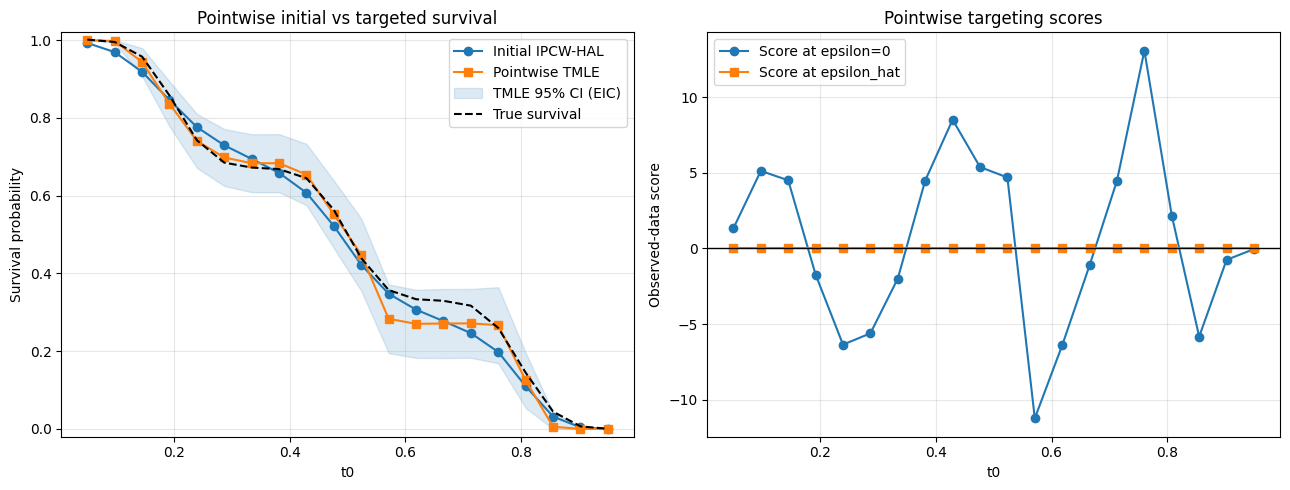

n_targets                    2.000000e+01
n_converged                  2.000000e+01
max_standard_error           4.990863e-02
max_abs_score_at_solution    1.330380e-11
n_score_roots                1.900000e+01
n_fallback_optimizations     1.000000e+00
dtype: float64

In [12]:
# 6) Compare pointwise initial and targeted survival, then compare their scores
fine_grid = np.linspace(0.001, 0.999, 4000)
fine_delta = np.diff(np.linspace(0.0, 1.0, 4001))
true_density_fine = sampler.compute_density(fine_grid)
true_survival_fine = np.cumsum((true_density_fine * fine_delta)[::-1])[::-1]
true_survival_target = np.interp(TARGET_TIMES, fine_grid, true_survival_fine, left=1.0, right=0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(TARGET_TIMES, curve_summary['psi_init'], marker='o', label='Initial IPCW-HAL')
axes[0].plot(TARGET_TIMES, curve_summary['psi_star'], marker='s', label='Pointwise TMLE')
axes[0].fill_between(
    TARGET_TIMES,
    curve_summary['ci_lower'],
    curve_summary['ci_upper'],
    color='tab:blue',
    alpha=0.15,
    label='TMLE 95% CI (EIC)',
)
axes[0].plot(TARGET_TIMES, true_survival_target, linestyle='--', color='black', label='True survival')
axes[0].set_xlabel('t0')
axes[0].set_ylabel('Survival probability')
axes[0].set_title('Pointwise initial vs targeted survival')
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(TARGET_TIMES, curve_summary['score_at_zero'], marker='o', label='Score at epsilon=0', color='tab:blue')
axes[1].plot(TARGET_TIMES, curve_summary['score_at_solution'], marker='s', label='Score at epsilon_hat', color='tab:orange')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_xlabel('t0')
axes[1].set_ylabel('Observed-data score')
axes[1].set_title('Pointwise targeting scores')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

pd.Series({
    "n_targets": int(len(curve_summary)),
    "n_converged": int(curve_summary['converged'].sum()),
    "max_standard_error": float(np.max(curve_summary['standard_error'])),
    "max_abs_score_at_solution": float(np.max(np.abs(curve_summary['score_at_solution']))),
    "n_score_roots": int((curve_summary['solve_method'] == 'score_root').sum()),
    "n_fallback_optimizations": int((curve_summary['solve_method'] == 'bounded_fallback').sum()),
})


## Selected Density Comparisons

Each target time has its own pointwise targeted density. To keep the notebook readable, we show six selected target times below in a `2 x 3` layout, comparing the Stage 1 density, the pointwise targeted density, and the truth.


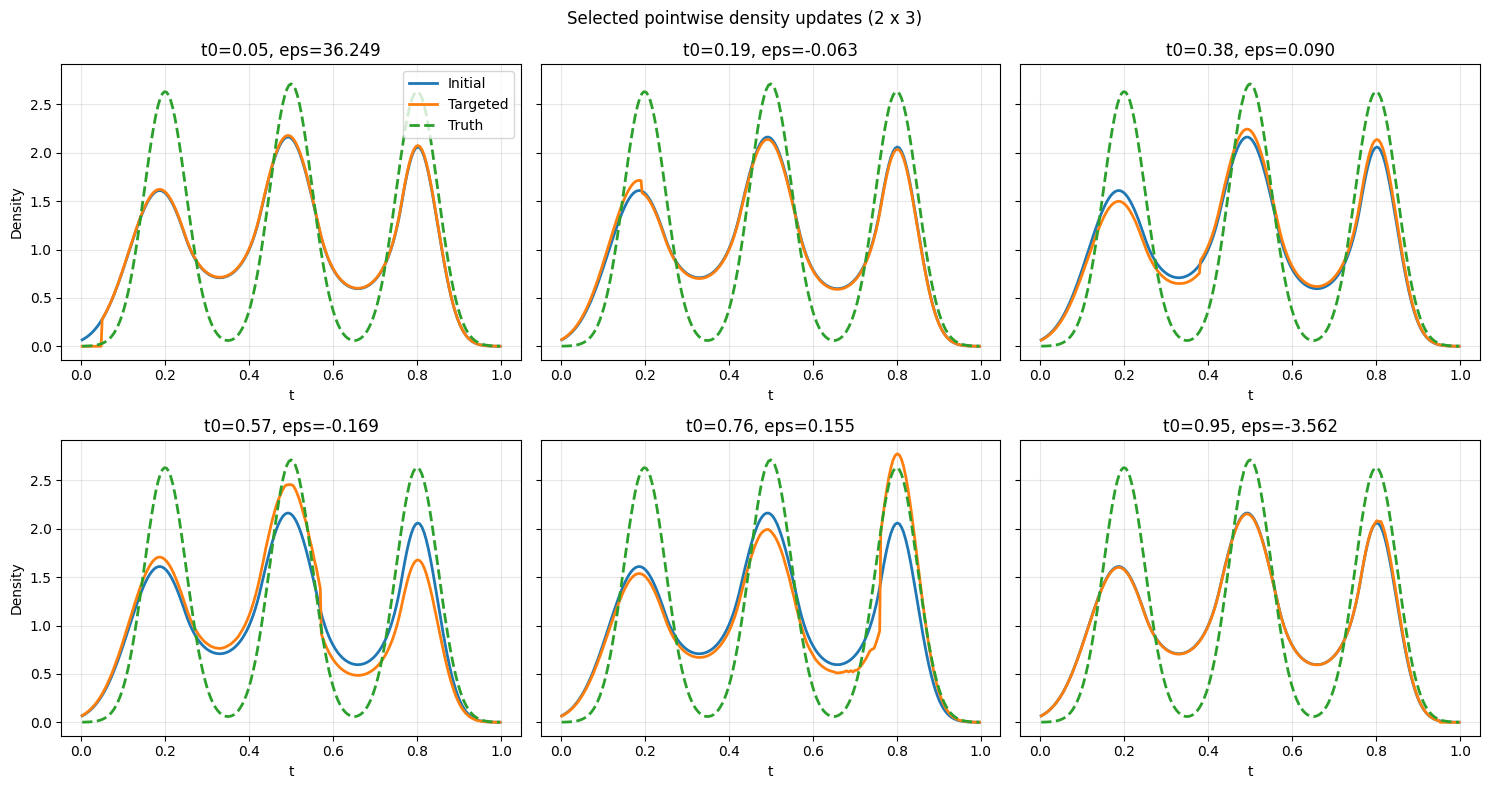

,t0,psi_init,psi_star,epsilon,target_grid_augmented_with_t0
0,0.050000,0.992575,1.000000e+00,36.249125,True
1,0.192105,0.845765,8.361507e-01,-0.063234,True
2,0.381579,0.658477,6.833941e-01,0.089943,True
3,0.571053,0.347676,2.832879e-01,-0.169380,True
4,0.760526,0.197971,2.667463e-01,0.154672,True
5,0.950000,0.000214,8.009616e-16,-3.561797,True


In [11]:
# 7) Show six pointwise density comparisons in a 2 x 3 layout
density_plot_indices = np.linspace(0, len(TARGET_TIMES) - 1, 6, dtype=int)
density_plot_times = TARGET_TIMES[density_plot_indices]

density_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=density_plot_times,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
density_results = {float(fit['t0']): fit for fit in density_targeted['pointwise_fits']}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
density_rows = []
for ax, density_t0 in zip(axes.ravel(), density_plot_times):
    result = density_results[float(density_t0)]
    density_grid = result['target_grid_midpoints']
    density_before = result['density_before_grid']
    density_after = result['estimated_density']
    density_truth = sampler.compute_density(density_grid)
    ax.plot(density_grid, density_before, label='Initial', linewidth=2)
    ax.plot(density_grid, density_after, label='Targeted', linewidth=2)
    ax.plot(density_grid, density_truth, label='Truth', linestyle='--', linewidth=2)
    ax.set_title(f't0={density_t0:.2f}, eps={result["epsilon"]:.3f}')
    ax.set_xlabel('t')
    ax.grid(alpha=0.3)
    density_rows.append({
        "t0": float(density_t0),
        "psi_init": result['psi_init'],
        "psi_star": result['psi_star'],
        "epsilon": result['epsilon'],
        "target_grid_augmented_with_t0": result['target_grid_augmented_with_t0'],
    })

axes[0, 0].set_ylabel('Density')
axes[1, 0].set_ylabel('Density')
axes[0, 0].legend()
fig.suptitle('Selected pointwise density updates (2 x 3)')
plt.tight_layout()
plt.show()

pd.DataFrame(density_rows)


## Optional Focus-Time Summary

The focus-time fit is still available above if we want to inspect one `t0` in more detail. The main v1 notebook now keeps three compact views: survival, scores, and six selected density comparisons.


In [10]:
focus_summary = pd.Series({
    "t0": focus_result['t0'],
    "psi_init": focus_result['psi_init'],
    "psi_star": focus_result['psi_star'],
    "epsilon": focus_result['epsilon'],
    "score_at_zero": focus_result['score_at_zero'],
    "score_at_solution": focus_result['score_at_solution'],
    "standard_error": focus_result['standard_error'],
    "ci_lower": focus_result['ci_lower'],
    "ci_upper": focus_result['ci_upper'],
    "solve_method": focus_result['solve_method'],
})
focus_summary


t0                          0.5
psi_init               0.471029
psi_star               0.469324
epsilon               -0.004398
score_at_zero         -0.304917
score_at_solution          -0.0
standard_error         0.046648
ci_lower               0.377895
ci_upper               0.560754
solve_method         score_root
dtype: object

## Notes

This v1 notebook is intentionally compact. It keeps the Stage 1 IPCW initializer and the right-censored TMLE API visible, but it avoids carrying every intermediate direction and grid diagnostic into the main workflow.

For multiple target times, the API still performs one separate scalar update per `t0`, so a 20-point target grid means 20 pointwise targeted fits. The notebook now summarizes those fits through three compact comparisons: survival values, observed-data scores, and six selected density panels in a `2 x 3` layout.
